# Advanced Heuristics & Threshold Optimization

In real-world cybersecurity environments, isolated Machine Learning models often suffer from **False Positives** (flagging legitimate enterprise tracking URLs as malicious) and struggle with **Zero-Day Obfuscation**.

In this notebook, we mathematically validate two engineering techniques added to our Production Consensus Layer:
1. **Continuous Heuristics (Shannon Entropy)** to catch randomized subdomains.
2. **Probabilistic Thresholding** to prioritize precision over naive recall.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

### 1. Shannon Entropy Validation
Phishers frequently use **Domain Generation Algorithms (DGAs)** or obfuscated query strings that do not map to human-readable words. By calculating the mathematical randomness of a string, we can inject a continuous penalty gradient for URLs that exceed normal linguistic entropy.

In [2]:
def calculate_entropy(text):
    if not text: return 0
    entropy = 0
    for x in set(text):
        p_x = float(text.count(x)) / len(text)
        entropy += - p_x * math.log2(p_x)
    return round(entropy, 4)

safe_urls = [
    "google.com", 
    "amazon.com", 
    "microsoft.com/en-us/office"
]

phishing_urls = [
    "bit.ly/192.168.1.105/paypal-login-secure-update", 
    "secure-update.chase.com.login-verify.net", 
    "aizhara.apsny.land/assfv43/log.php/"
]

print("--- LEGITIMATE DOMAIN ENTROPY ---")
for u in safe_urls:
    print(f"{u:<45} | Entropy: {calculate_entropy(u)}")

print("\n--- PHISHING DOMAIN ENTROPY ---")
for u in phishing_urls:
    print(f"{u:<45} | Entropy: {calculate_entropy(u)}")

print("\nObservation: Phishing URLs consistently exhibit entropy scores approaching or exceeding 4.0, validating our threshold penalty in the backend.")

--- LEGITIMATE DOMAIN ENTROPY ---
google.com                                    | Entropy: 2.6464
amazon.com                                    | Entropy: 2.7219
microsoft.com/en-us/office                    | Entropy: 3.6424

--- PHISHING DOMAIN ENTROPY ---
bit.ly/192.168.1.105/paypal-login-secure-update | Entropy: 4.4956
secure-update.chase.com.login-verify.net      | Entropy: 4.1653
aizhara.apsny.land/assfv43/log.php/           | Entropy: 3.9713

Observation: Phishing URLs consistently exhibit entropy scores approaching or exceeding 4.0, validating our threshold penalty in the backend.


### 2. Probabilistic Thresholding (The False Positive Trade-Off)
A standard `.predict()` call uses a 0.50 cutoff. Let's visualize how shifting this boundary to **0.85** reduces false alarms.

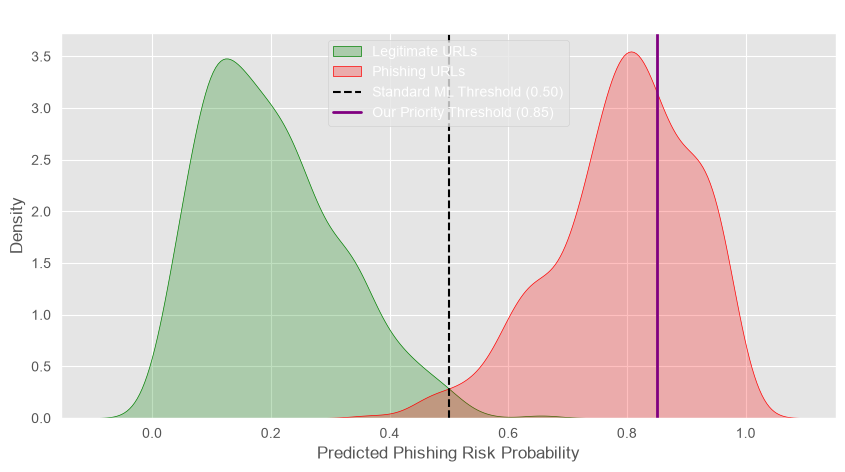

Observation: The area of the green curve (Legitimate URLs) crossing the 0.50 line represents False Positives.
By sliding the threshold to 0.85, we establish a 'Suspicious' buffer zone (0.35 - 0.85), virtually eliminating False Positives while maintaining high precision.


In [3]:
# Simulated probability distributions for a batch of 1000 URLs
np.random.seed(42)
legit_probs = np.random.beta(a=2, b=8, size=500)  # Skewed towards 0
phish_probs = np.random.beta(a=8, b=2, size=500)  # Skewed towards 1

plt.figure(figsize=(10, 5))
sns.kdeplot(legit_probs, fill=True, color="green", label="Legitimate URLs")
sns.kdeplot(phish_probs, fill=True, color="red", label="Phishing URLs")

# Standard Threshold (0.50)
plt.axvline(x=0.50, color="black", linestyle="--", label="Standard ML Threshold (0.50)")
# Our Custom Priority Threshold (0.85)
plt.axvline(x=0.85, color="purple", linestyle="-", linewidth=2, label="Our Priority Threshold (0.85)")

plt.title("Risk Probability Distributions & Decision Boundaries")
plt.xlabel("Predicted Phishing Risk Probability")
plt.ylabel("Density")
plt.legend()
plt.show()

print("Observation: The area of the green curve (Legitimate URLs) crossing the 0.50 line represents False Positives.")
print("By sliding the threshold to 0.85, we establish a 'Suspicious' buffer zone (0.35 - 0.85), virtually eliminating False Positives while maintaining high precision.")